### 4.5.1 约束区域

前文讨论的试验区域均为超立方体,但实际场景中部分因子组合不可行.例如,高压与高温同时出现会引发系统故障,这类组合便无需开展试验.设输入可行域由一组约束定义:

$$\mathcal{X}=\{\boldsymbol{x}\in[0,1]^p:g_{k}(\boldsymbol{x})\le0,\;\forall k\}\tag{4.29}$$

其中$\{g_{k}(\boldsymbol{x})\le0\}_{k=1}^{K}$为$K$个任意不等式约束.约束函数可以是黑箱函数,且评估成本较高.下面给出黄等人(2021)的简易算例:

$$\begin{align*}&g_{1}(x)=x_{1}-\sqrt{50(x_{2}-0.52)^2+2}+1\le0,\\&g_{2}(x)=\sqrt{120\left((x_{2}-0.48)^2+1\right)}-0.75-x_{1}\le0,\\&g_{3}(x)=0.65^{2}-x_{1}^2-x_{2}^2\le0,\\&\text{其中}\;0\le x_{1},x_{2}\le1\end{align*}\tag{4.30}$$

可行域如图4.15阴影区域所示.假定试验预算允许开展20次试验.

>**图4.15** 阴影区域为式(4.30)中约束条件对应的可行域

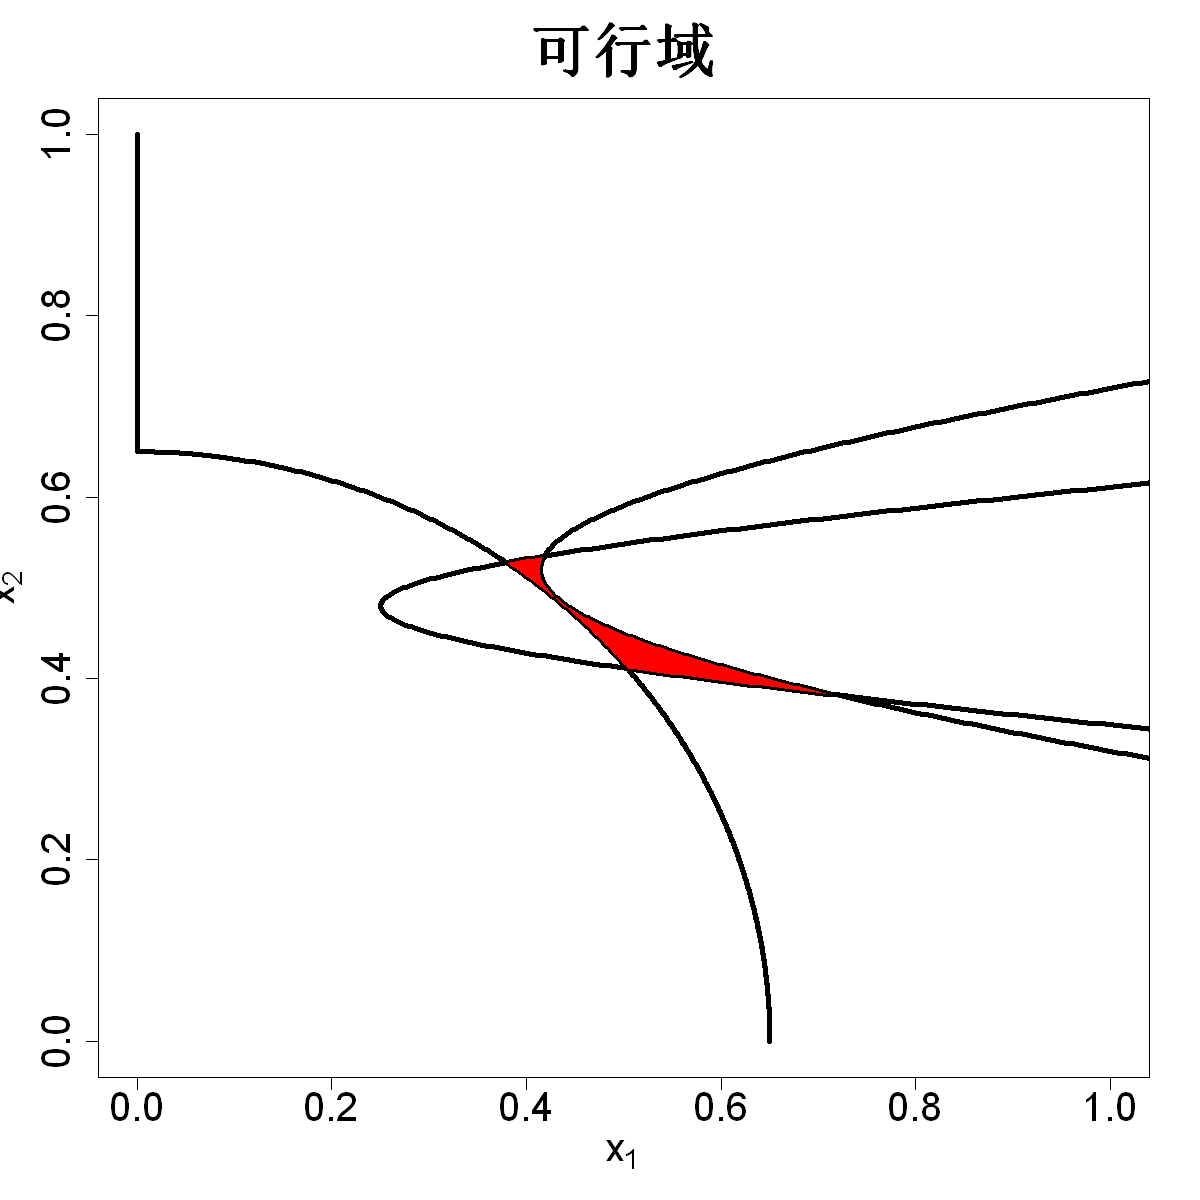

In [2]:
#图4.15

options(repr.plot.width=10,repr.plot.height=10)
constraint=function(x)
{
c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
c3=(0.65^2-x[1]^2-x[2]^2)
return(c(c1,c2,c3))
}
x1=x2=matrix(0,nrow=3,ncol=1001)
x2.seq=seq(0,1,length=1001)
x2[1,]=x2.seq;x2[2,]=x2.seq;x2[3,]=x2.seq
x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
x1[3,]=sqrt(pmax(0,0.65^2-x2.seq^2))
plot(NULL,type="n",xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="可行域",cex.main=3)
contour=list(x1=x1,x2=x2)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],lwd=4)
ix12=which(diff(sign(contour$x1[1,]-contour$x1[2,]))!=0)
ix23=which(diff(sign(contour$x1[2,]-contour$x1[3,]))!=0)
polygon(x=c(contour$x1[1,ix12[1]:ix12[2]],contour$x1[2,ix12[2]:ix23[2]],contour$x1[3,ix23[2]:ix23[1]],contour$x1[2,ix23[1]:ix12[1]]),y=c(contour$x2[1,ix12[1]:ix12[2]],contour$x2[2,ix12[2]:ix23[2]],contour$x2[3,ix23[2]:ix23[1]],contour$x2[2,ix23[1]:ix12[1]]),col="red")

下面给出一种在约束区域内生成试验设计的通用流程:(i)首先在包围可行域的超立方体内生成大量均匀样本;(ii)剔除不满足约束条件的样本;(iii)在剩余样本(候选集)中选取试验设计点.针对式(4.30)对应的试验区域构造20个设计点:首先生成10000个随机拉丁超立方样本,如图4.16左图所示.剔除不满足式(4.30)的点后剩余538个点,构成候选集,见图4.16中图.随后可采用式(4.27)的序贯最大投影方法得到最大投影设计,结果如图4.16右图.后文4.6.2节将介绍一种更优的候选集生成方法,以此进一步提升最大投影设计的质量.

>**图4.16** 10000个拉丁超立方样本(左图),可行点集合(中图)以及最大投影设计(右图)

In [4]:
#图4.16

options(repr.plot.width=30,repr.plot.height=10)
par(mfrow=c(1,3))
constraint=function(x)
{
c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
c3=(0.65^2-x[1]^2-x[2]^2)
return(c(c1,c2,c3))
}
x1=x2=matrix(0,nrow=3,ncol=1001)
x2.seq=seq(0,1,length=1001)
x2[1,]=x2.seq;x2[2,]=x2.seq;x2[3,]=x2.seq
x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
x1[3,]=sqrt(pmax(0,0.65^2-x2.seq^2))
contour=list(x1=x1,x2=x2)

N=1e5
set.seed(1)
library(lhs)
lhs.all=randomLHS(N,2)
plot(lhs.all,col="green",pch=16,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="初始点",cex.lab=2,cex.main=4,cex.axis=2)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],lwd=4)

lhs.gval=t(apply(lhs.all,1,constraint))
lhs.out.idx=apply(lhs.gval,1,function(x)return(any(x>0)))
lhs.feasible=lhs.all[!lhs.out.idx,]
plot(lhs.feasible,col="red",pch=16,xlim=c(.3,.8),ylim=c(.35,.55),xlab=expression(x[1]),ylab=expression(x[2]),main="候选点",cex.lab=2,cex.main=4,cex.axis=2)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],lwd=4)

n=20
library(MaxPro)
lhs.maxpro=MaxProAugment(ExistDesign=lhs.feasible[1,],CandDesign=lhs.feasible[-1,],nNew=n-1)$Design
plot(lhs.maxpro,col="blue",pch=16,cex=3,xlim=c(.3,.8),ylim=c(.35,.55),xlab=expression(x[1]),ylab=expression(x[2]),main="最大投影设计",cex.lab=2,cex.main=4,cex.axis=2)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],lwd=4)
par(mfrow=c(1,1))